In [1]:
import wrds
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
db = wrds.Connection(wrds_username="你的用户名", wrds_password="你的密码")
print("连接成功")
# 查看表结构
print(db.describe_table(library="crsp", table="dsf"))

Enter your WRDS username [你的用户名]: zhiyuan1024
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  n


You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
连接成功
Approximately 107682104 rows in crsp.dsf.
       name  nullable              type  \
0     cusip      True        VARCHAR(8)   
1    permno      True           INTEGER   
2    permco      True           INTEGER   
3    issuno      True           INTEGER   
4     hexcd      True          SMALLINT   
5    hsiccd      True           INTEGER   
6      date      True              DATE   
7     bidlo      True    NUMERIC(11, 5)   
8     askhi      True    NUMERIC(11, 5)   
9       prc      True    NUMERIC(11, 5)   
10      vol      True    NUMERIC(10, 0)   
11      ret      True    NUMERIC(10, 6)   
12      bid      True    NUMERIC(11, 5)   
13      ask      True    NUMERIC(11, 5)   
14   shrout      True  DOUBLE PRECISION   
15   cfacpr      True  DOUBLE PRECISION   
16  cfacshr      True  DOUBLE PRECISION   
17  openprc      True    NUMERIC(11, 5)   
18   numtrd      True

In [9]:
query = """
    SELECT permno, date, prc, ret, vol, shrout
    FROM crsp.dsf
    WHERE permno = 14593
      AND date BETWEEN '2020-01-01' AND '2023-12-31'
    LIMIT 1000
"""
df = db.raw_sql(query)
print(df.head())
db.close()

   permno        date        prc       ret         vol     shrout
0   14593  2020-01-02  300.35001  0.022816  33884314.0  4384027.0
1   14593  2020-01-03  297.42999 -0.009722  36604600.0  4384027.0
2   14593  2020-01-06  299.79999  0.007968  29597401.0  4384027.0
3   14593  2020-01-07  298.39001 -0.004703  27864170.0  4384027.0
4   14593  2020-01-08     303.19  0.016086  33060420.0  4384027.0


In [10]:
print(df.describe())

        permno         prc       ret              vol          shrout
count   1000.0      1000.0    1000.0           1000.0          1000.0
mean   14593.0    182.1265  0.001227     77951115.449    14241444.272
std        0.0   74.860193  0.021207  36715353.332342  4458268.617641
min    14593.0      106.84 -0.128647       20012702.0       4275634.0
25%    14593.0      138.91 -0.009145      52833146.75      15634232.0
50%    14593.0  156.794995  0.001132       72369551.5      16070752.0
75%    14593.0     180.115  0.012967       93531427.5      16530166.0
max    14593.0      506.09  0.119808      331572938.0      17102536.0


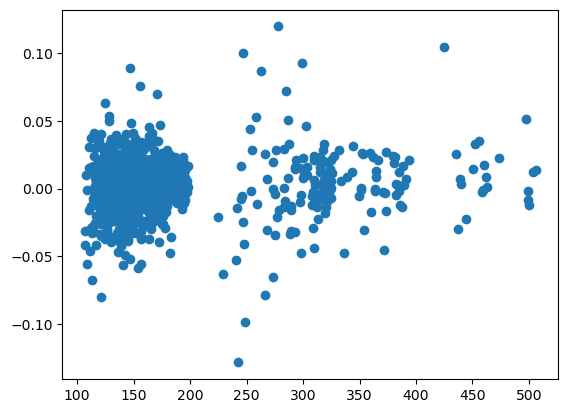

In [11]:
plt.scatter(df['prc'], df['ret'])
plt.show()